1) Problem statement

This project understands how the student's performance (test scores) is affected by other variables such as Gender, Ethnicity, Parental level of education, Lunch and Test preparation course.

2) Data Collection

Dataset Source - https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?datasetId=74977
The data consists of 8 column and 1000 rows.

2.1 Import Data and Required Packages

Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library.

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

Import the CSV Data as Pandas DataFrame

In [8]:
df = pd.read_csv('stud.csv')

Show Top 5 Records

In [9]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


Shape of the dataset

In [10]:
df.shape

(1000, 8)

## 2.2 Dataset Information

- **gender**: sex of students → (Male / Female)

- **race/ethnicity**: ethnicity of students → (Group A, Group B, Group C, Group D, Group E)

- **parental level of education**: parents' final education →  
  (Bachelor's degree, Some college, Master's degree, Associate's degree, High school)

- **lunch**: having lunch before test → (Standard / Free or Reduced)

- **test preparation course**: completion status before test → (Completed / Not Completed)

- **math score**: score in mathematics

- **reading score**: score in reading

- **writing score**: score in writing

## 3. Data Checks to Perform

- Check missing values  
- Check duplicates  
- Check data types  
- Check the number of unique values of each column  
- Check statistics of the dataset  
- Check various categories present in different categorical columns  

### 3.1 Check Missing Values

In [11]:
df.isna().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

## 3. Data Checks to Perform

### 3.1 Check Missing Values
There are no missing values in the data set.

### 3.2 Check Duplicates

In [12]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(0)


There are no duplicate values in the data set.

### 3.3 Check Data Types

In [14]:
# Check Null and Dtypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


3.4 Checking the number of unique values of each column

In [15]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

3.5 Check statistics of data set

In [16]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


### Insight
From above description of numerical data:  
- All means are very close to each other — between 66 and 68.05.  
- All standard deviations are also close — between 14.6 and 15.19.  
- While there is a minimum score of 0 for Math, for Writing minimum is much higher = 10, and for Reading yet higher = 17.

### 3.7 Exploring Data

In [17]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [18]:
print("Categories in 'gender' variable:     ",end=" " )
print(df['gender'].unique())

print("Categories in 'race_ethnicity' variable:  ",end=" ")
print(df['race_ethnicity'].unique())

print("Categories in'parental level of education' variable:",end=" " )
print(df['parental_level_of_education'].unique())

print("Categories in 'lunch' variable:     ",end=" " )
print(df['lunch'].unique())

print("Categories in 'test preparation course' variable:     ",end=" " )
print(df['test_preparation_course'].unique())

Categories in 'gender' variable:      ['female' 'male']
Categories in 'race_ethnicity' variable:   ['group B' 'group C' 'group A' 'group D' 'group E']
Categories in'parental level of education' variable: ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categories in 'lunch' variable:      ['standard' 'free/reduced']
Categories in 'test preparation course' variable:      ['none' 'completed']


In [19]:
# define numerical & categorical columns
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

# print columns
print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 3 numerical features : ['math_score', 'reading_score', 'writing_score']

We have 5 categorical features : ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


In [20]:
df.head(2)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88


### 3.8 Adding Columns for "Total Score" and "Average"

In [21]:
df['total score'] = df['math_score'] + df['reading_score'] + df['writing_score']
df['average'] = df['total score']/3
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [22]:
reading_full = df[df['reading_score'] == 100]['average'].count()
writing_full = df[df['writing_score'] == 100]['average'].count()
math_full = df[df['math_score'] == 100]['average'].count()

print(f'Number of students with full marks in Maths: {math_full}')
print(f'Number of students with full marks in Writing: {writing_full}')
print(f'Number of students with full marks in Reading: {reading_full}')

Number of students with full marks in Maths: 7
Number of students with full marks in Writing: 14
Number of students with full marks in Reading: 17


In [23]:
reading_less_20 = df[df['reading_score'] <= 20]['average'].count()
writing_less_20 = df[df['writing_score'] <= 20]['average'].count()
math_less_20 = df[df['math_score'] <= 20]['average'].count()

print(f'Number of students with less than 20 marks in Maths: {math_less_20}')
print(f'Number of students with less than 20 marks in Writing: {writing_less_20}')
print(f'Number of students with less than 20 marks in Reading: {reading_less_20}')

Number of students with less than 20 marks in Maths: 4
Number of students with less than 20 marks in Writing: 3
Number of students with less than 20 marks in Reading: 1


### Insights
From above values:  
- Students have performed the worst in **Maths**.  
- Best performance is in **Reading** section.

## 4. Exploring Data (Visualization)

### 4.1 Visualize Average Score Distribution to Make Some Conclusion
- Histogram  
- Kernel Density Estimate (KDE)

#### 4.1.1 Histogram & KDE

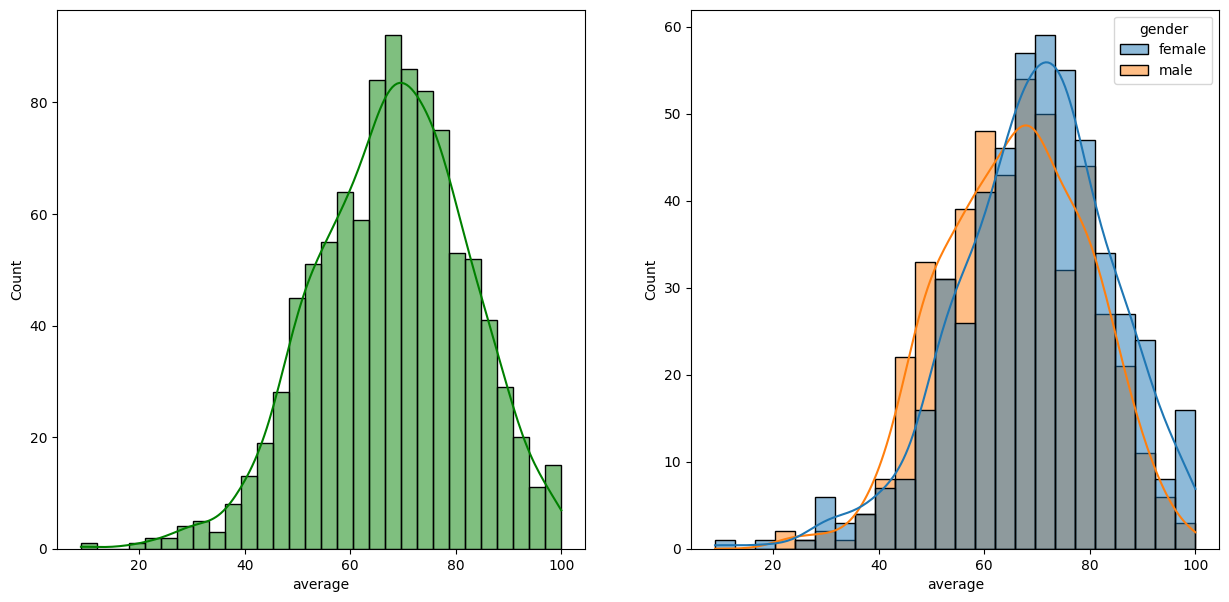

In [25]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(121)
sns.histplot(data=df,x='average',bins=30,kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df,x='average',kde=True,hue='gender')
plt.show()

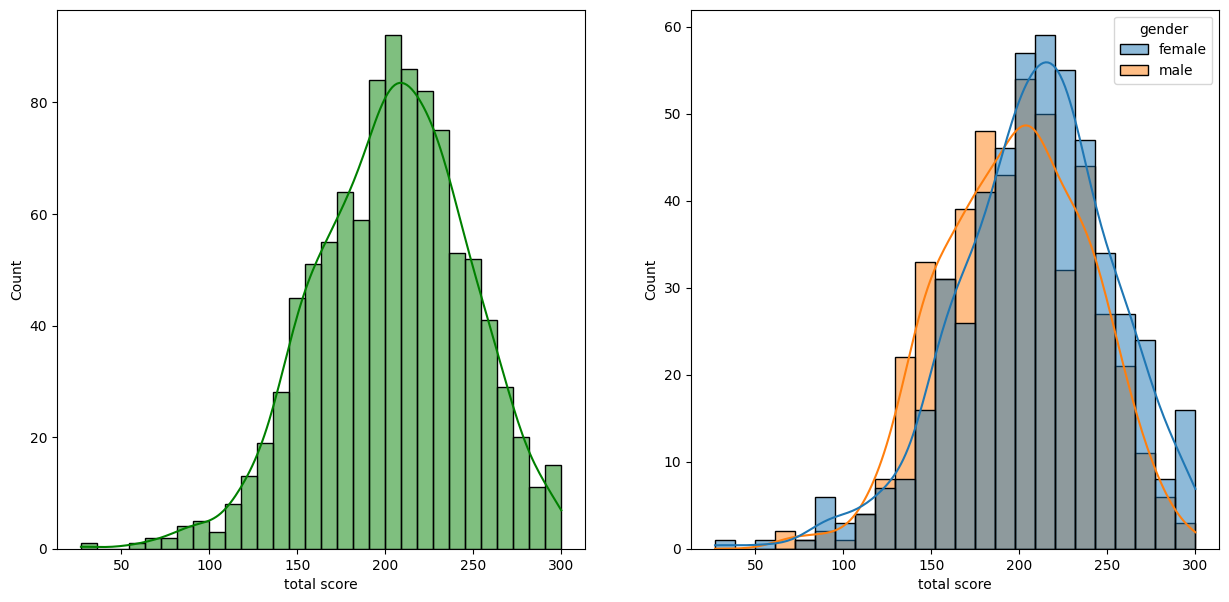

In [26]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(121)
sns.histplot(data=df,x='total score',bins=30,kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df,x='total score',kde=True,hue='gender')
plt.show()

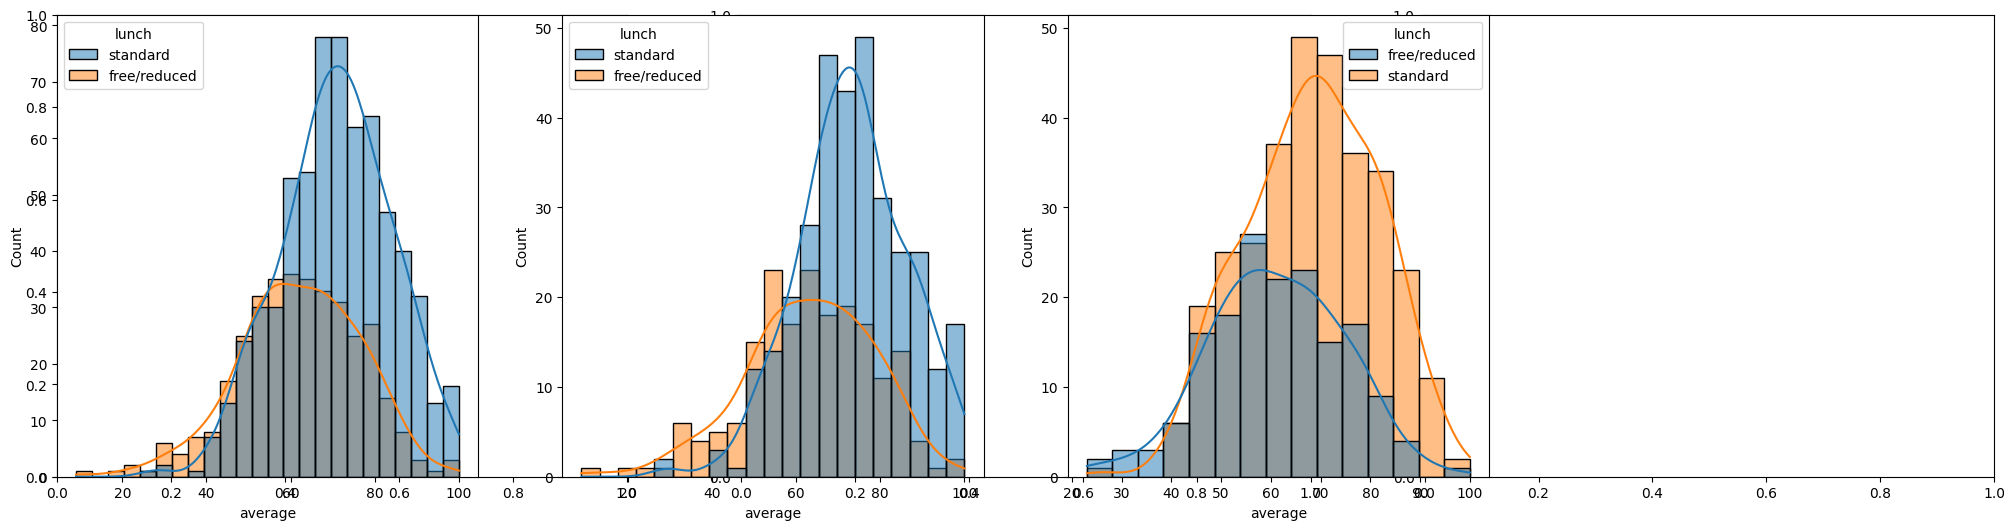

In [28]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
sns.histplot(data=df,x='average',kde=True,hue='lunch')
plt.subplot(142)
sns.histplot(data=df[df.gender=='female'],x='average',kde=True,hue='lunch')
plt.subplot(143)
sns.histplot(data=df[df.gender=='male'],x='average',kde=True,hue='lunch')
plt.show()

### Insights
- Standard lunch helps students perform well in exams.  
- Standard lunch helps students perform well in exams, whether male or female.

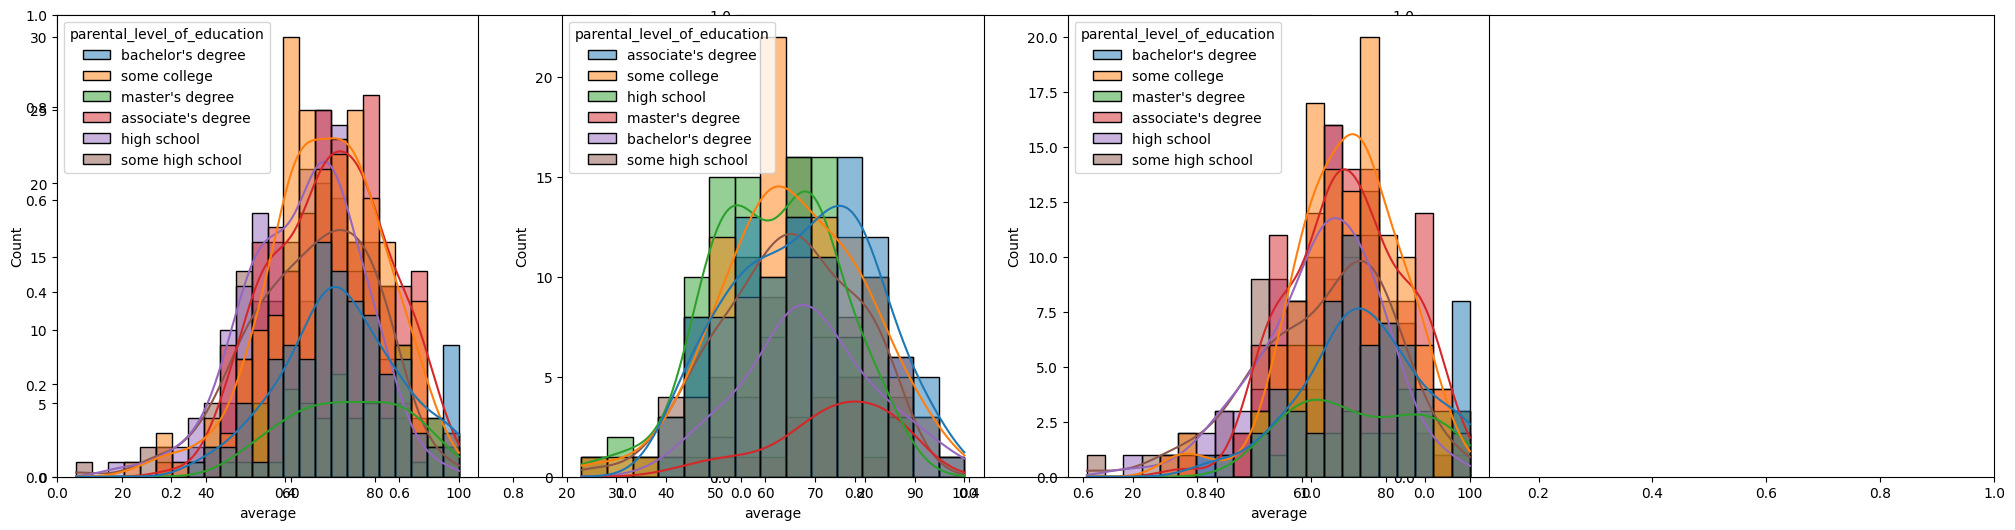

In [31]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
ax =sns.histplot(data=df,x='average',kde=True,hue='parental_level_of_education')
plt.subplot(142)
ax =sns.histplot(data=df[df.gender=='male'],x='average',kde=True,hue='parental_level_of_education')
plt.subplot(143)
ax =sns.histplot(data=df[df.gender=='female'],x='average',kde=True,hue='parental_level_of_education')
plt.show()

### Insights
- In general, parent's education doesn't help students perform well in exams.  
- 2nd plot shows that parents whose education is of **Associate's Degree** or **Master's Degree**, their **male child** tends to perform well in exams.  
- 3rd plot shows there is **no effect of parent's education on female students**.

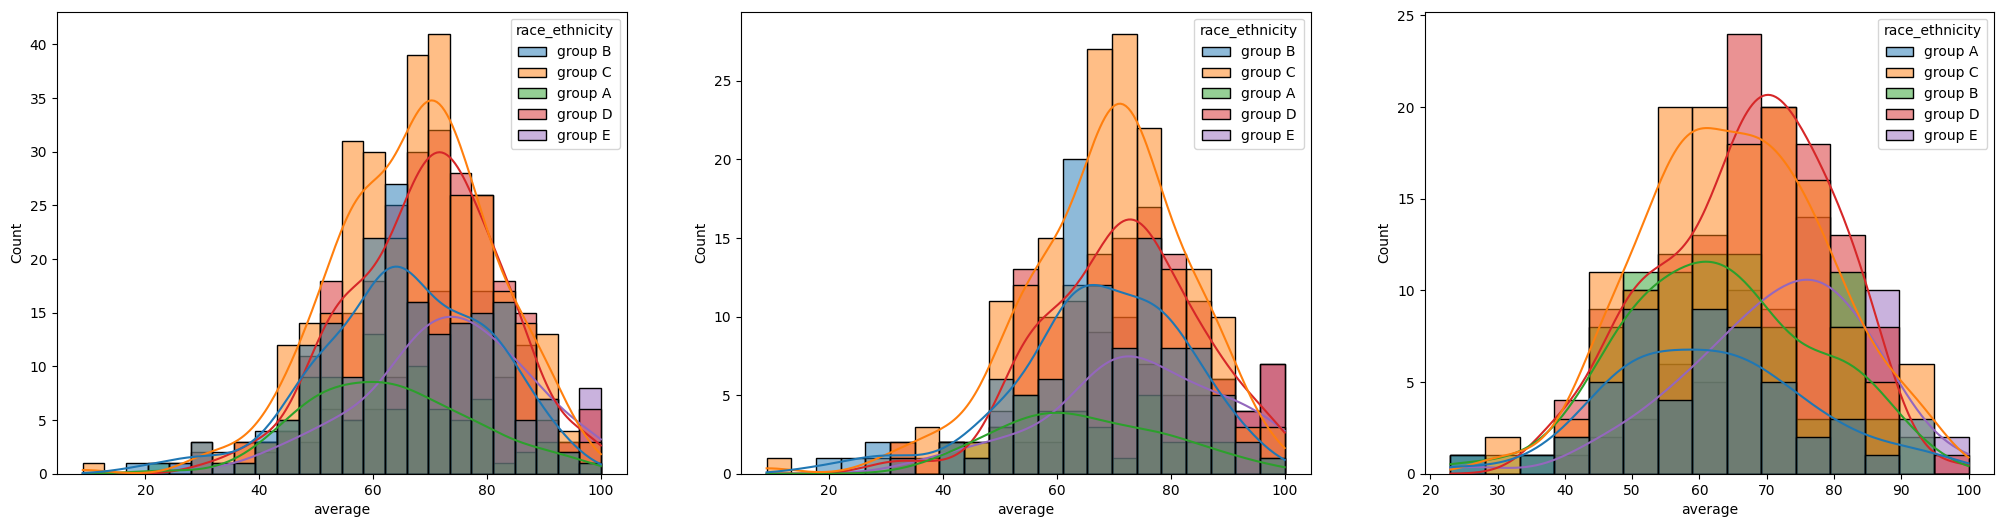

In [35]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(131)
ax = sns.histplot(data=df, x='average', kde=True, hue='race_ethnicity')
plt.subplot(132)
ax = sns.histplot(data=df[df.gender=='female'], x='average', kde=True, hue='race_ethnicity')
plt.subplot(133)
ax = sns.histplot(data=df[df.gender=='male'], x='average', kde=True, hue='race_ethnicity')
plt.show()

## Insights

- Students belonging to **Group A** and **Group B** tend to perform poorly in exams.  
- This trend remains consistent **irrespective of gender (male or female)**.

## 4.2 Maximum Score of Students in All Three Subjects

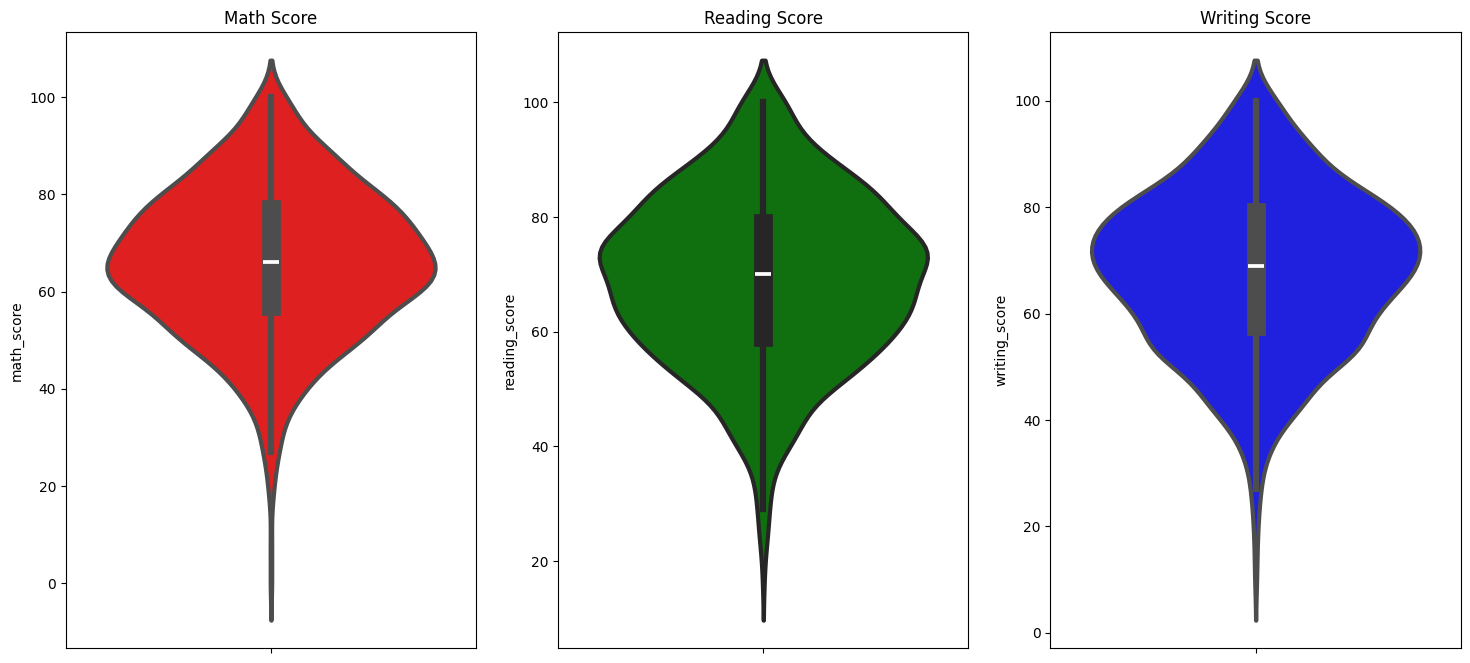

In [38]:
plt.figure(figsize=(18,8))

plt.subplot(1, 3, 1)
plt.title('Math Score')
sns.violinplot(y='math_score', data=df, color='red', linewidth=3)

plt.subplot(1, 3, 2)
plt.title('Reading Score')
sns.violinplot(y='reading_score', data=df, color='green', linewidth=3)

plt.subplot(1, 3, 3)
plt.title('Writing Score')
sns.violinplot(y='writing_score', data=df, color='blue', linewidth=3)

plt.show()

## Insights

- From the above three plots, it is clearly visible that most students score **between 60-80 in Maths**, whereas in **Reading** and **Writing**, most of them score **between 50-80**.

## 4.3 Multivariate Analysis Using Pie Plot

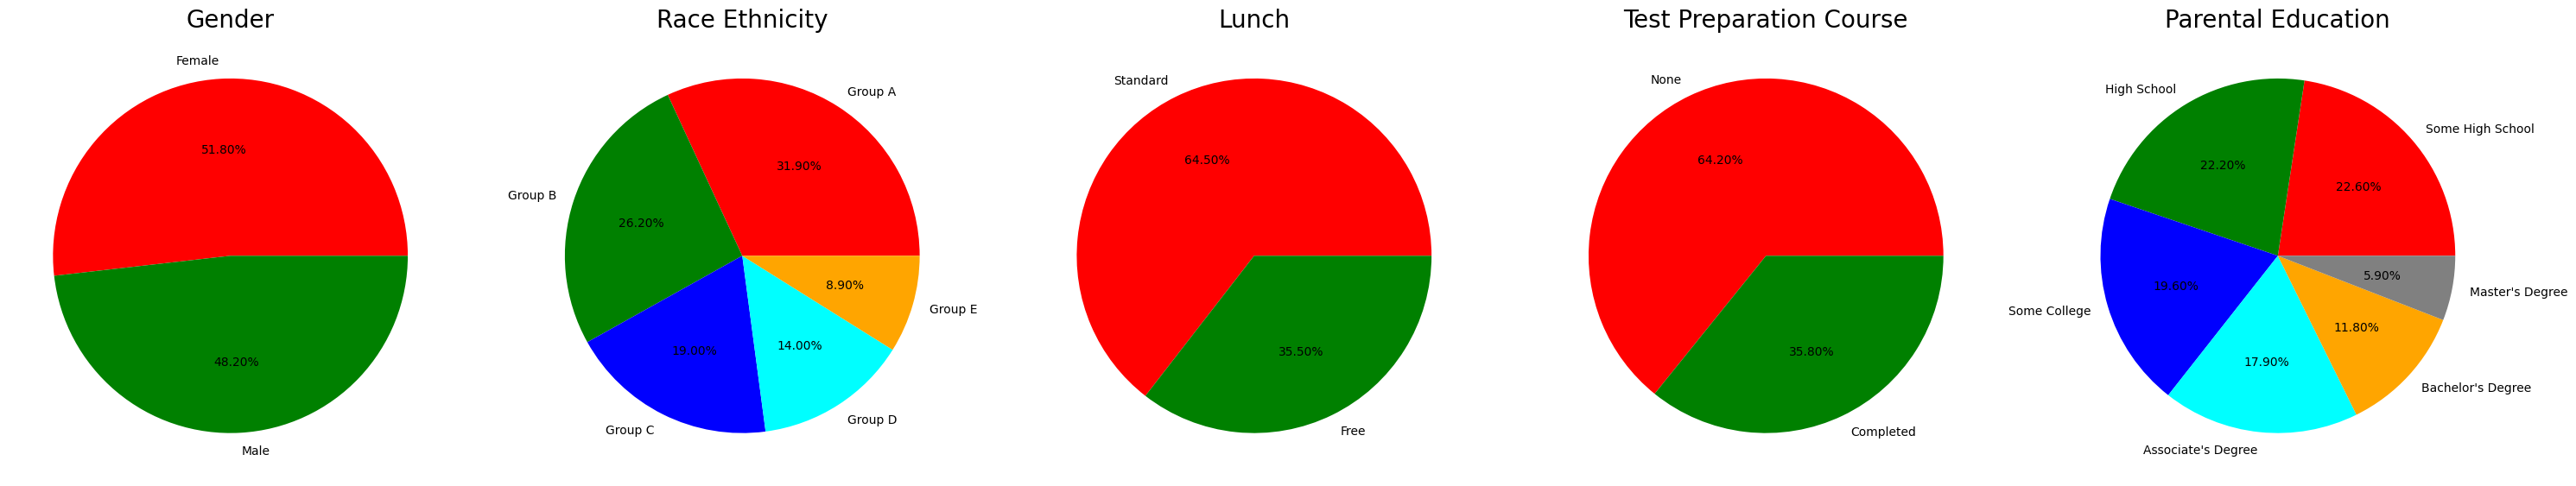

In [40]:
plt.rcParams['figure.figsize'] = (30, 12)

# Gender
plt.subplot(1, 5, 1)
size = df['gender'].value_counts()
labels = ['Female', 'Male']
colors = ['red','green']
plt.pie(size, colors=colors, labels=labels, autopct='%1.2f%%')
plt.title('Gender', fontsize=20)
plt.axis('off')

# Race/Ethnicity
plt.subplot(1, 5, 2)
size = df['race_ethnicity'].value_counts()
labels = ['Group A','Group B','Group C','Group D','Group E']  # alphabetical order
colors = ['red', 'green', 'blue', 'cyan','orange']
plt.pie(size, colors=colors, labels=labels, autopct='%1.2f%%')
plt.title('Race Ethnicity', fontsize=20)
plt.axis('off')

# Lunch
plt.subplot(1, 5, 3)
size = df['lunch'].value_counts()
labels = ['Standard', 'Free']
colors = ['red','green']
plt.pie(size, colors=colors, labels=labels, autopct='%1.2f%%')
plt.title('Lunch', fontsize=20)
plt.axis('off')

# Test Preparation Course
plt.subplot(1, 5, 4)
size = df['test_preparation_course'].value_counts()
labels = ['None', 'Completed']
colors = ['red','green']
plt.pie(size, colors=colors, labels=labels, autopct='%1.2f%%')
plt.title('Test Preparation Course', fontsize=20)
plt.axis('off')

# Parental Level of Education
plt.subplot(1, 5, 5)
size = df['parental_level_of_education'].value_counts()
labels = ["Some High School", "High School", "Some College", "Associate's Degree", "Bachelor's Degree","Master's Degree"]
colors = ['red', 'green', 'blue', 'cyan','orange','grey']
plt.pie(size, colors=colors, labels=labels, autopct='%1.2f%%')
plt.title('Parental Education', fontsize=20)
plt.axis('off')

plt.tight_layout()
plt.show()

## Insights

- Number of **male** and **female** students is almost equal.  
- Number of students is greatest in **Group C**.  
- Number of students who have **standard lunch** is higher.  
- Number of students who have **not enrolled in any test preparation course** is higher.  
- Number of students whose **parental education** is "**Some College**" is highest, followed closely by "**Associate's Degree**".  

## 4.4 Feature Wise Visualization

### 4.4.1 Gender Column

**Key Questions:**  
- How is the distribution of **Gender**?  
- Does **Gender** have any impact on student's performance?  

#### Univariate Analysis
- Focuses on the distribution of **Gender** to understand the overall pattern in the dataset.

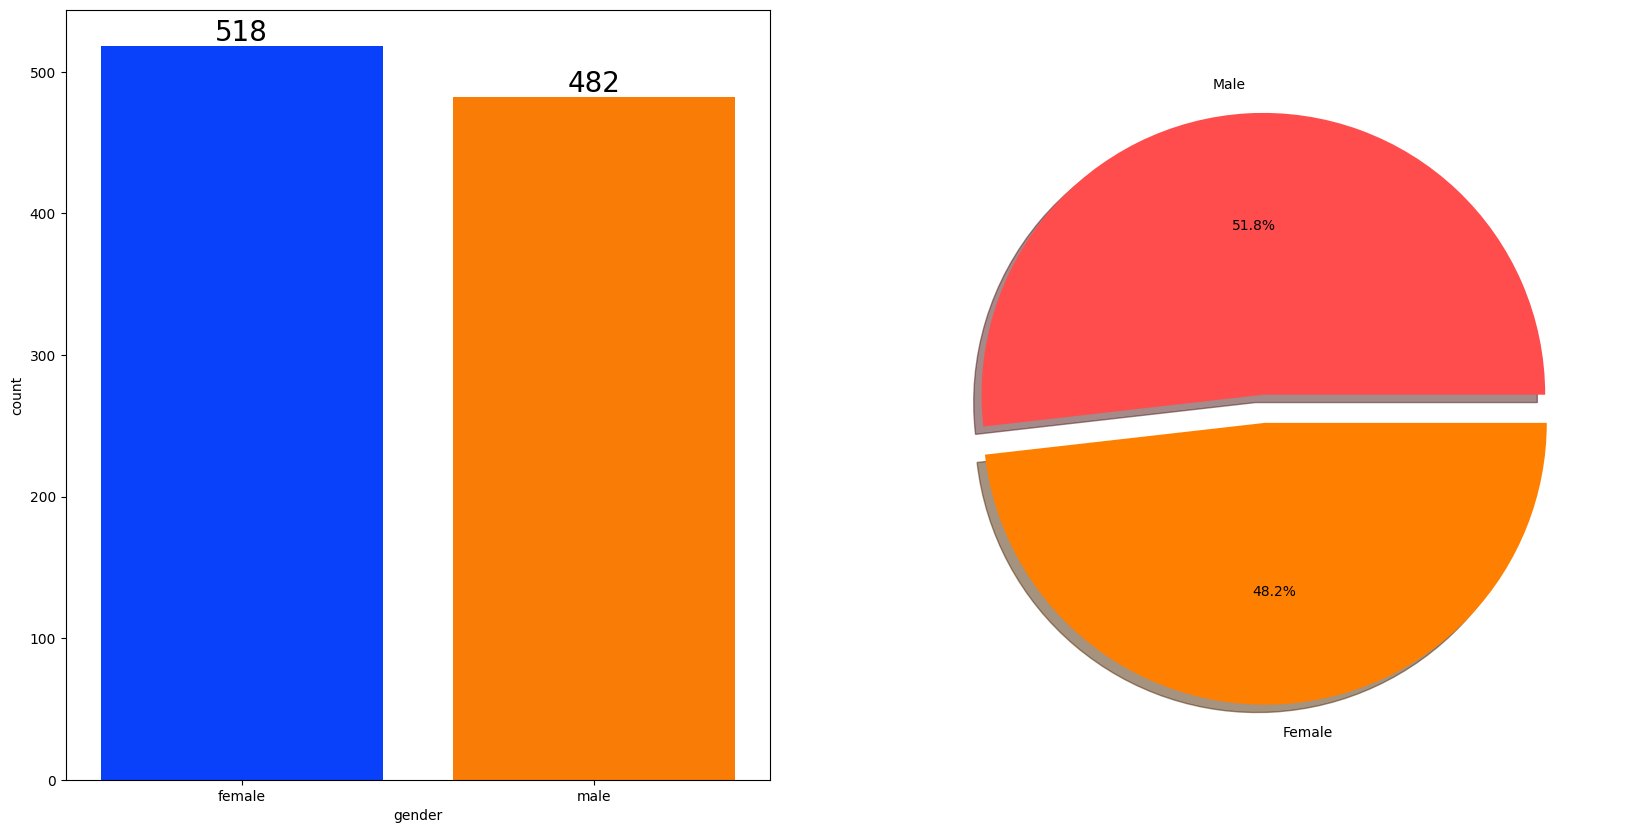

In [42]:
f,ax=plt.subplots(1,2,figsize=(20,10))
sns.countplot(x=df['gender'],data=df,palette ='bright',ax=ax[0],saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
    
plt.pie(x=df['gender'].value_counts(),labels=['Male','Female'],explode=[0,0.1],autopct='%1.1f%%',shadow=True,colors=['#ff4d4d','#ff8000'])
plt.show()

## Insights

- Gender data is fairly balanced:  
  - **Female students:** 518 (48%)  
  - **Male students:** 482 (52%)  

## Bivariate Analysis

**Key Question:**  
- Does **Gender** have any impact on student's performance?

In [45]:

gender_group = df.groupby('gender')[['math_score', 'reading_score', 'writing_score', 'total score', 'average']].mean()
gender_group

,math_score,reading_score,writing_score,total score,average
gender,,,,,
female,63.633205,72.608108,72.467181,208.708494,69.569498
male,68.728216,65.473029,63.311203,197.512448,65.837483


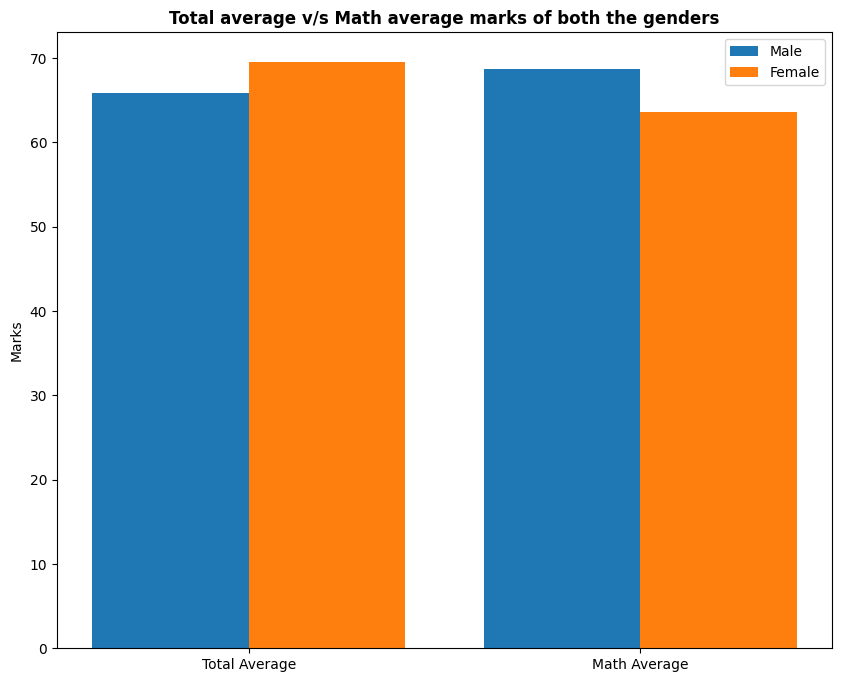

In [47]:
plt.figure(figsize=(10, 8))

X = ['Total Average','Math Average']


female_scores = [gender_group['average'][0], gender_group['math_score'][0]]
male_scores = [gender_group['average'][1], gender_group['math_score'][1]]

X_axis = np.arange(len(X))
  
plt.bar(X_axis - 0.2, male_scores, 0.4, label = 'Male')
plt.bar(X_axis + 0.2, female_scores, 0.4, label = 'Female')
  
plt.xticks(X_axis, X)
plt.ylabel("Marks")
plt.title("Total average v/s Math average marks of both the genders", fontweight='bold')
plt.legend()
plt.show()

## Insights

- On average, **female students** have a better overall score than males.  
- However, **male students** have scored higher in **Maths**.

## 4.4.2 Race/Ethnicity Column

**Key Questions:**  
- How is the **group-wise distribution**?  
- Does **Race/Ethnicity** have any impact on student's performance?  

#### Univariate Analysis
- This analysis focuses on understanding the **distribution of students across different groups (A, B, C, D, E)**.

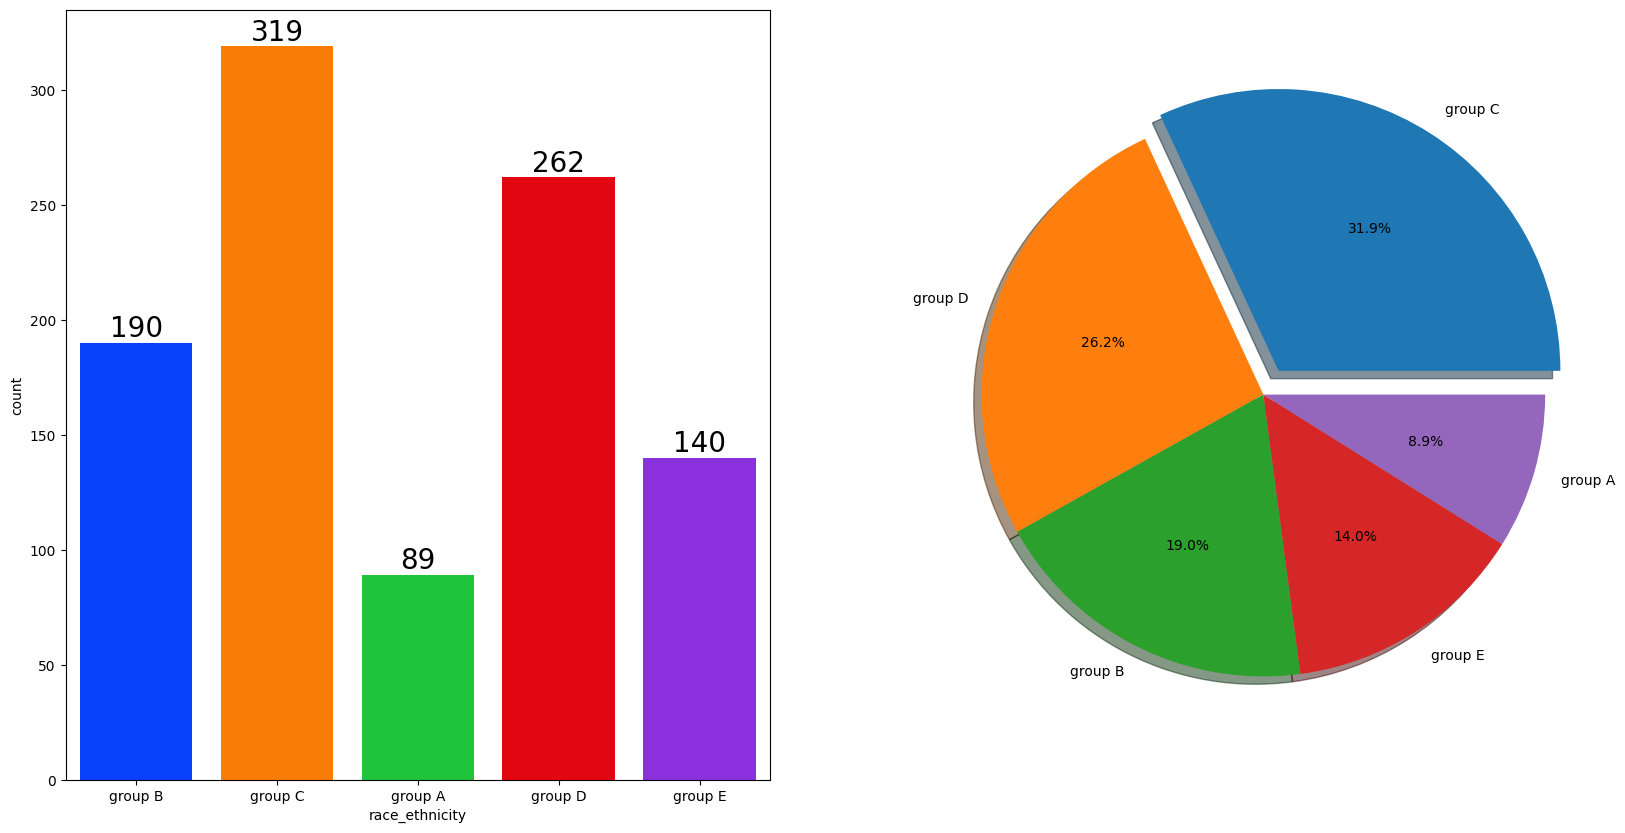

In [48]:
f,ax=plt.subplots(1,2,figsize=(20,10))
sns.countplot(x=df['race_ethnicity'],data=df,palette = 'bright',ax=ax[0],saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
    
plt.pie(x = df['race_ethnicity'].value_counts(),labels=df['race_ethnicity'].value_counts().index,explode=[0.1,0,0,0,0],autopct='%1.1f%%',shadow=True)
plt.show()   

## Insights

- Most of the students belong to **Group C** and **Group D**.  
- The lowest number of students belong to **Group A**.  

## Bivariate Analysis

**Key Question:**  
- Does **Race/Ethnicity** have any impact on student's performance?

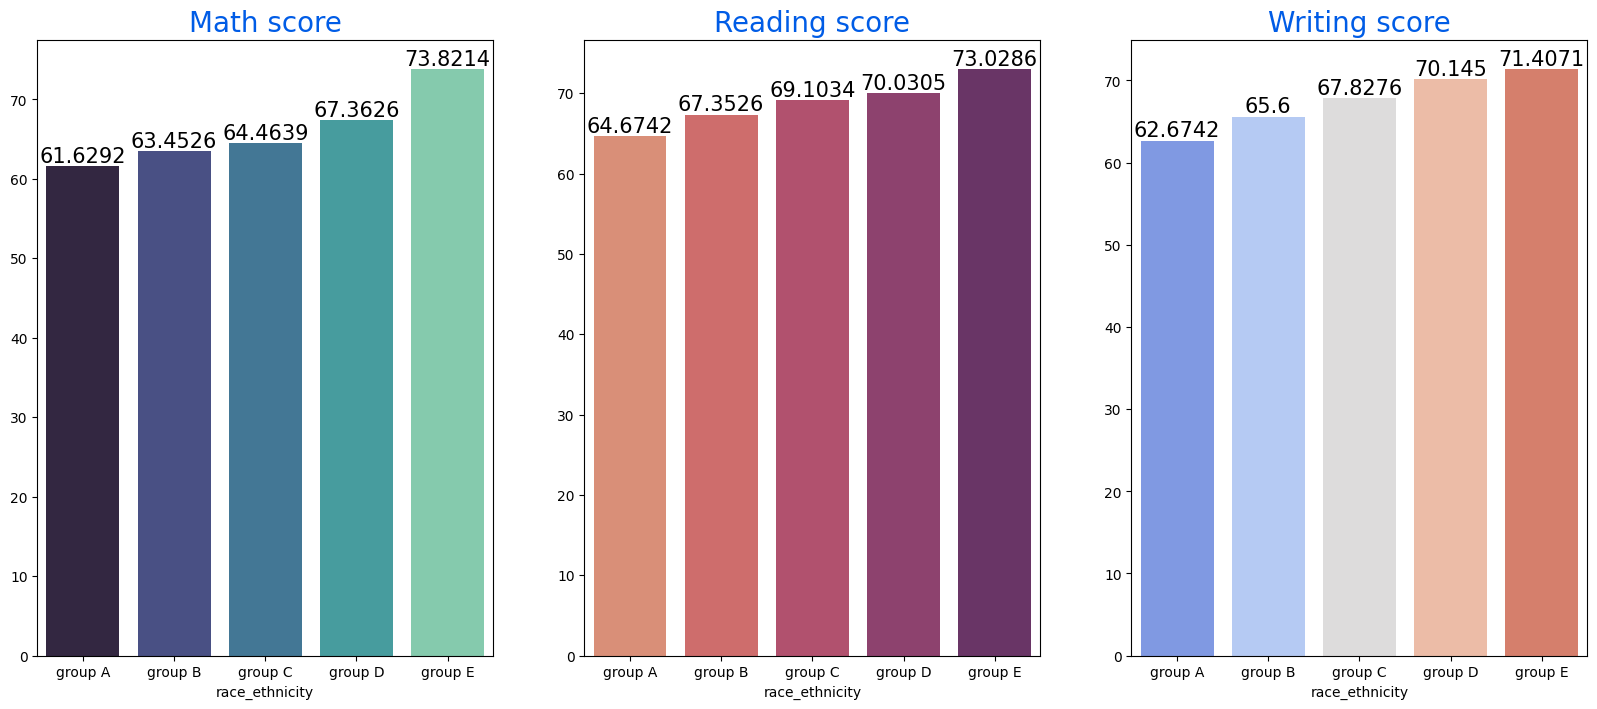

In [49]:
Group_data2=df.groupby('race_ethnicity')
f,ax=plt.subplots(1,3,figsize=(20,8))
sns.barplot(x=Group_data2['math_score'].mean().index,y=Group_data2['math_score'].mean().values,palette = 'mako',ax=ax[0])
ax[0].set_title('Math score',color='#005ce6',size=20)

for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=15)

sns.barplot(x=Group_data2['reading_score'].mean().index,y=Group_data2['reading_score'].mean().values,palette = 'flare',ax=ax[1])
ax[1].set_title('Reading score',color='#005ce6',size=20)

for container in ax[1].containers:
    ax[1].bar_label(container,color='black',size=15)

sns.barplot(x=Group_data2['writing_score'].mean().index,y=Group_data2['writing_score'].mean().values,palette = 'coolwarm',ax=ax[2])
ax[2].set_title('Writing score',color='#005ce6',size=20)

for container in ax[2].containers:
    ax[2].bar_label(container,color='black',size=15)

## Insights

- **Group E** students have scored the highest marks.  
- **Group A** students have scored the lowest marks.  
- Students from **lower socioeconomic status** tend to have lower average scores across all subjects.  

## 4.4.3 Parental Level of Education Column

**Key Questions:**  
- What is the educational background of students' parents?  
- Does **parental education** have any impact on student's performance?  

#### Univariate Analysis
- This analysis focuses on understanding the **distribution of parental education levels** among students.

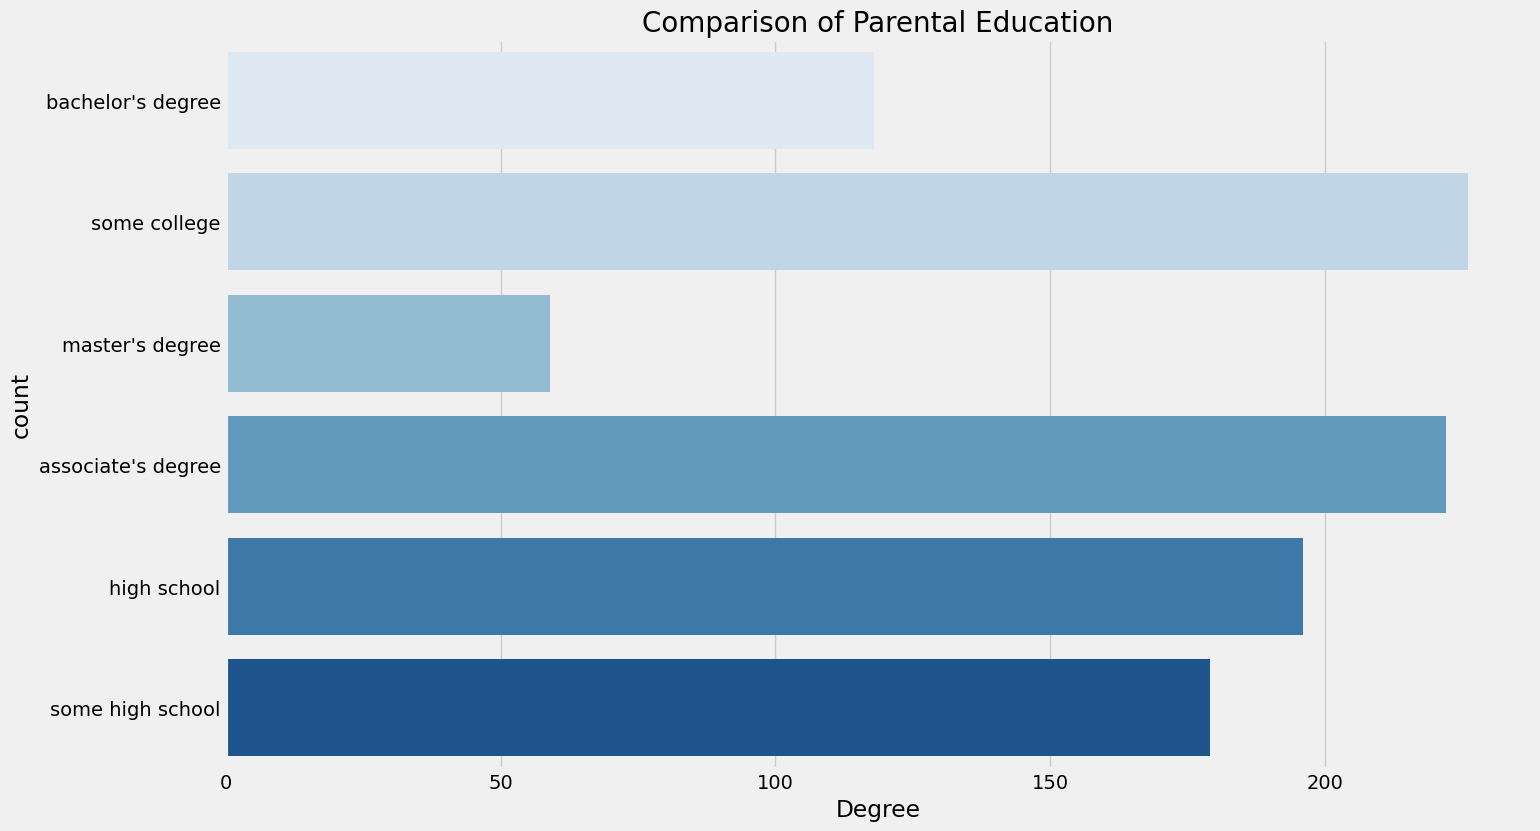

In [50]:
plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('fivethirtyeight')
sns.countplot(df['parental_level_of_education'], palette = 'Blues')
plt.title('Comparison of Parental Education', fontweight = 30, fontsize = 20)
plt.xlabel('Degree')
plt.ylabel('count')
plt.show()

## Insights

- The largest number of parents belong to the **"Some College"** category.  

## Bivariate Analysis

**Key Question:**  
- Does **parental education** have any impact on student's performance?

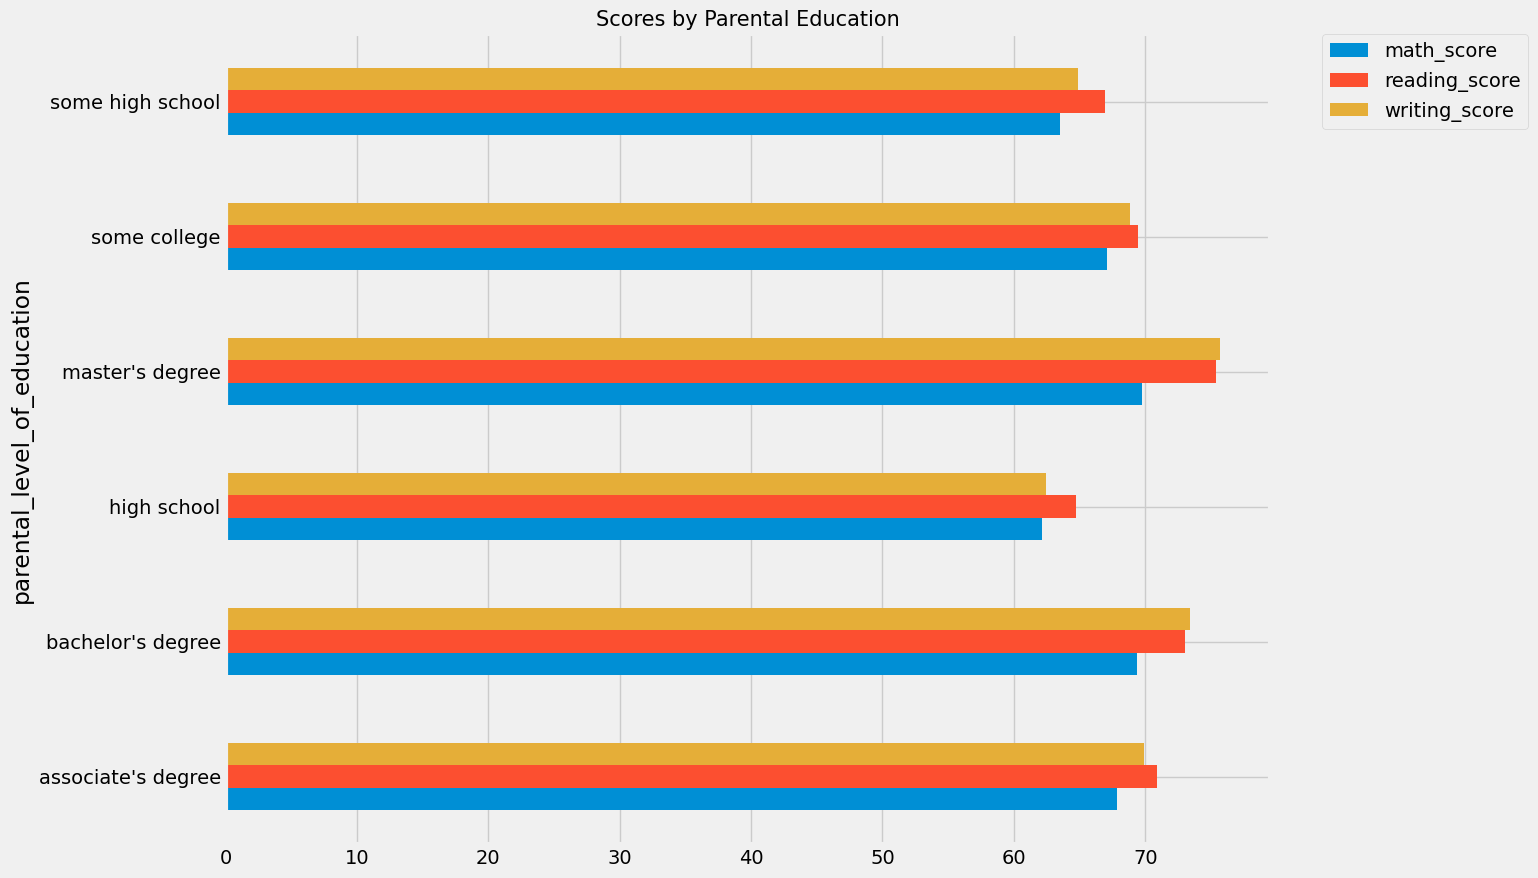

In [52]:
df.groupby('parental_level_of_education')[['math_score', 'reading_score', 'writing_score']].mean().plot(
    kind='barh', figsize=(12,10)
)

plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.title('Scores by Parental Education', fontsize=15)
plt.show()

## Insights

- Students whose parents have **Master’s** and **Bachelor’s** level education tend to score higher than others.  

## 4.4.4 Lunch Column

**Key Questions:**  
- Which type of lunch is most common among students?  
- What is the effect of lunch type on test results?  

#### Univariate Analysis
- This analysis focuses on identifying the **most common type of lunch** among students.

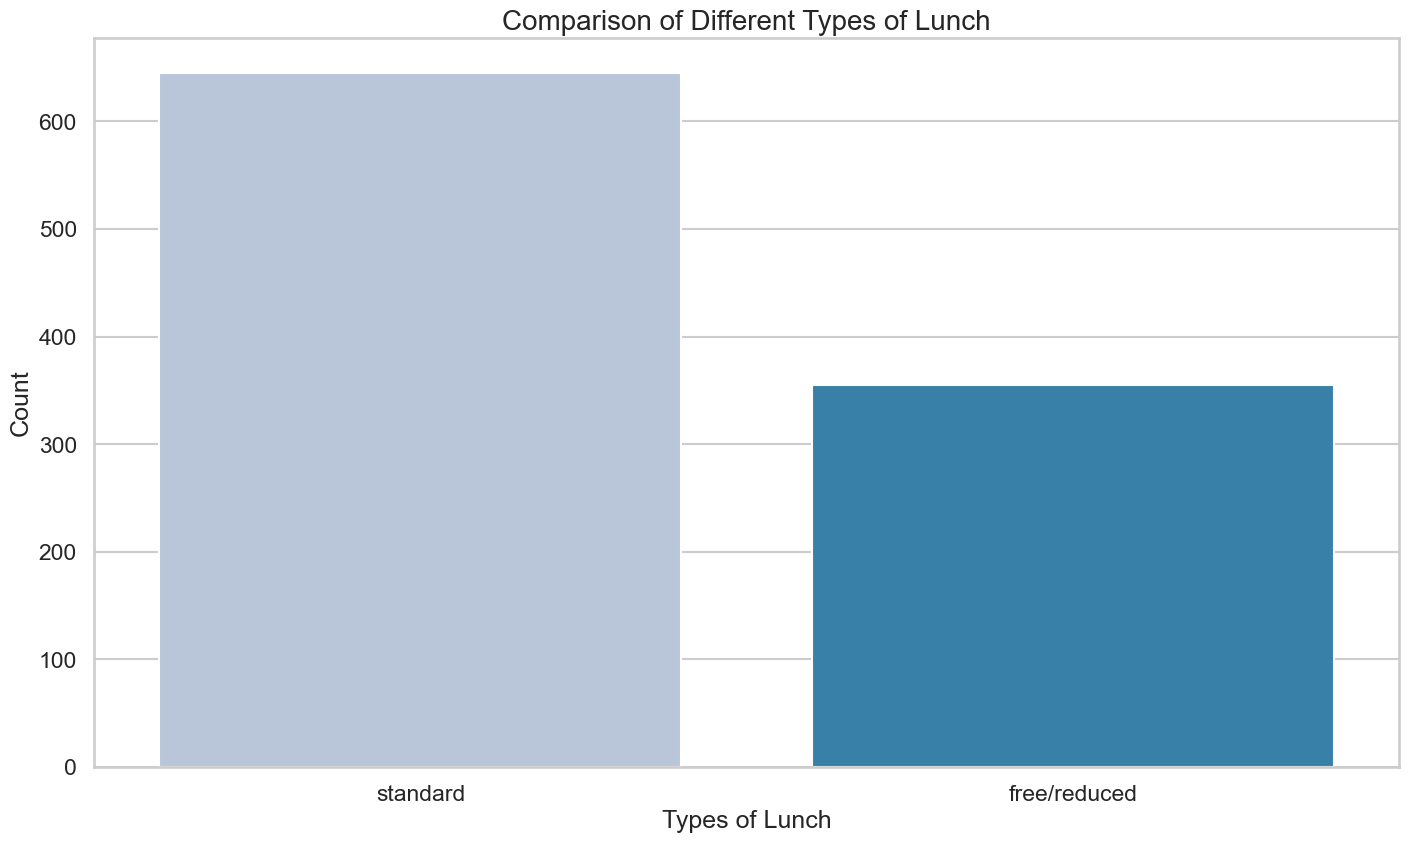

In [54]:
plt.rcParams['figure.figsize'] = (15, 9)

sns.set_style('whitegrid')
sns.set_context('talk')

sns.countplot(x='lunch', data=df, palette='PuBu')

plt.title('Comparison of Different Types of Lunch', fontsize=20)
plt.xlabel('Types of Lunch')
plt.ylabel('Count')

plt.show()

## Insights

- The number of students receiving **standard lunch** is higher than those receiving **free/reduced lunch**.  

## Bivariate Analysis

**Key Question:**  
- Does **lunch type** have any impact on student's performance?

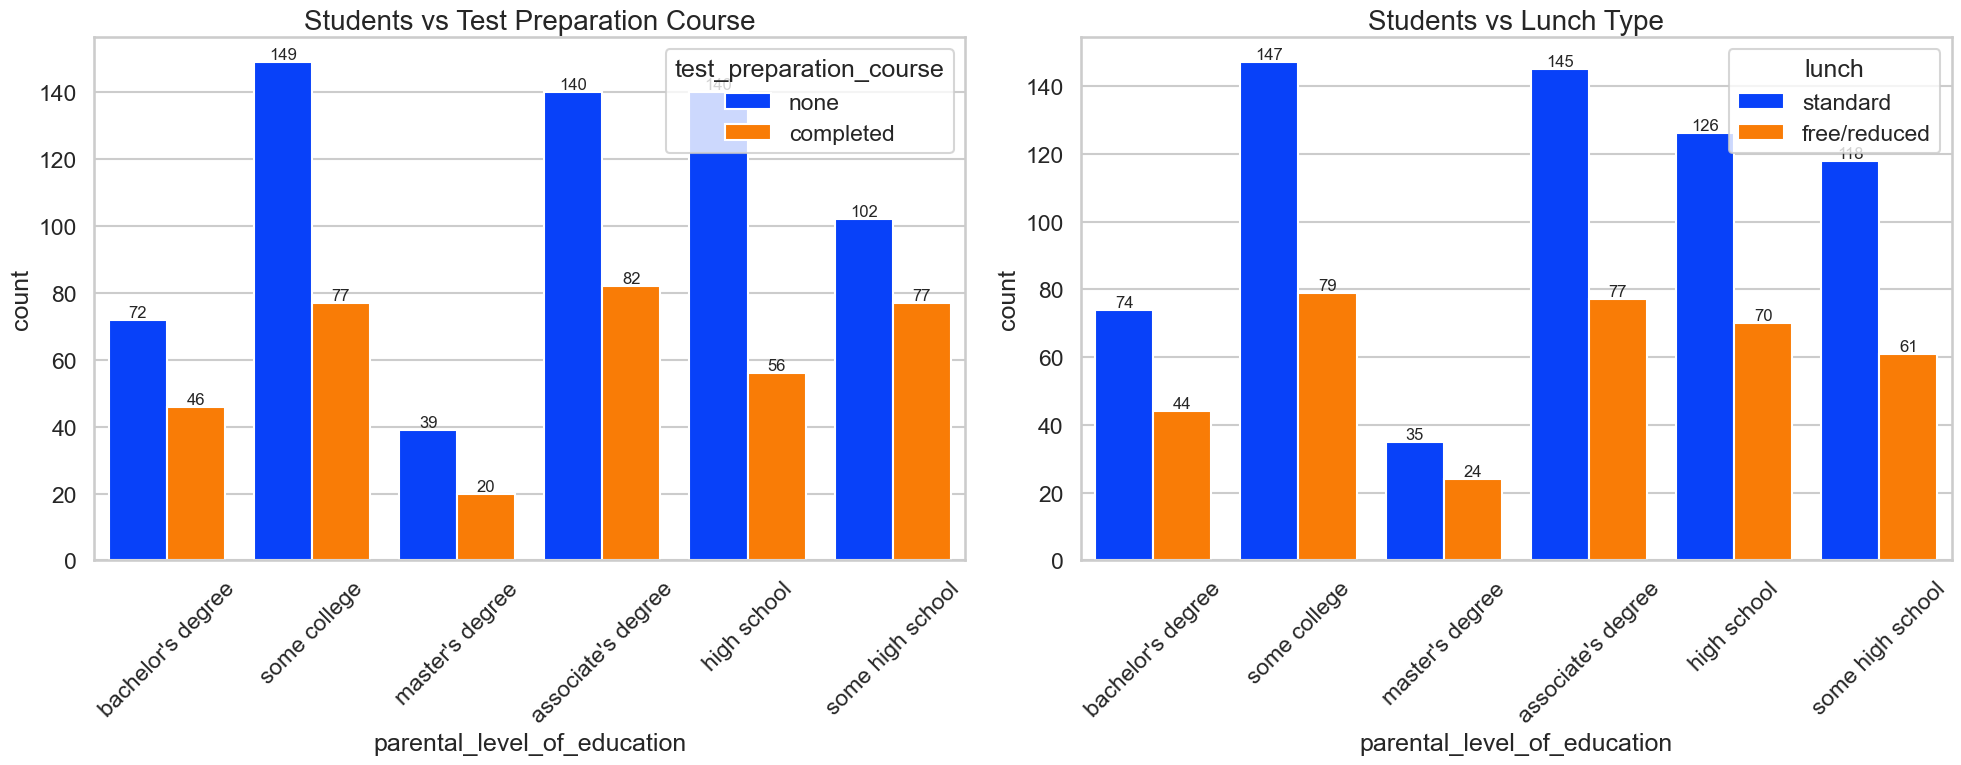

In [56]:
f, ax = plt.subplots(1, 2, figsize=(20,8))

# Plot 1: Test Preparation Course
sns.countplot(
    x='parental_level_of_education',
    data=df,
    palette='bright',
    hue='test_preparation_course',
    saturation=0.95,
    ax=ax[0]
)

ax[0].set_title('Students vs Test Preparation Course', size=20)
ax[0].tick_params(axis='x', rotation=45)

for container in ax[0].containers:
    ax[0].bar_label(container, size=12)


# Plot 2: Lunch
sns.countplot(
    x='parental_level_of_education',
    data=df,
    palette='bright',
    hue='lunch',
    saturation=0.95,
    ax=ax[1]
)

ax[1].set_title('Students vs Lunch Type', size=20)
ax[1].tick_params(axis='x', rotation=45)

for container in ax[1].containers:
    ax[1].bar_label(container, size=12)

plt.tight_layout()
plt.show()

## Insights

- Students who receive **standard lunch** tend to perform better than those who receive **free/reduced lunch**.  

## 4.4.5 Test Preparation Course Column

**Key Questions:**  
- Which type of **test preparation status** is most common among students?  
- Does the **test preparation course** have any impact on student's performance?  

## Bivariate Analysis

**Key Question:**  
- Does the **test preparation course** have any impact on student's performance?

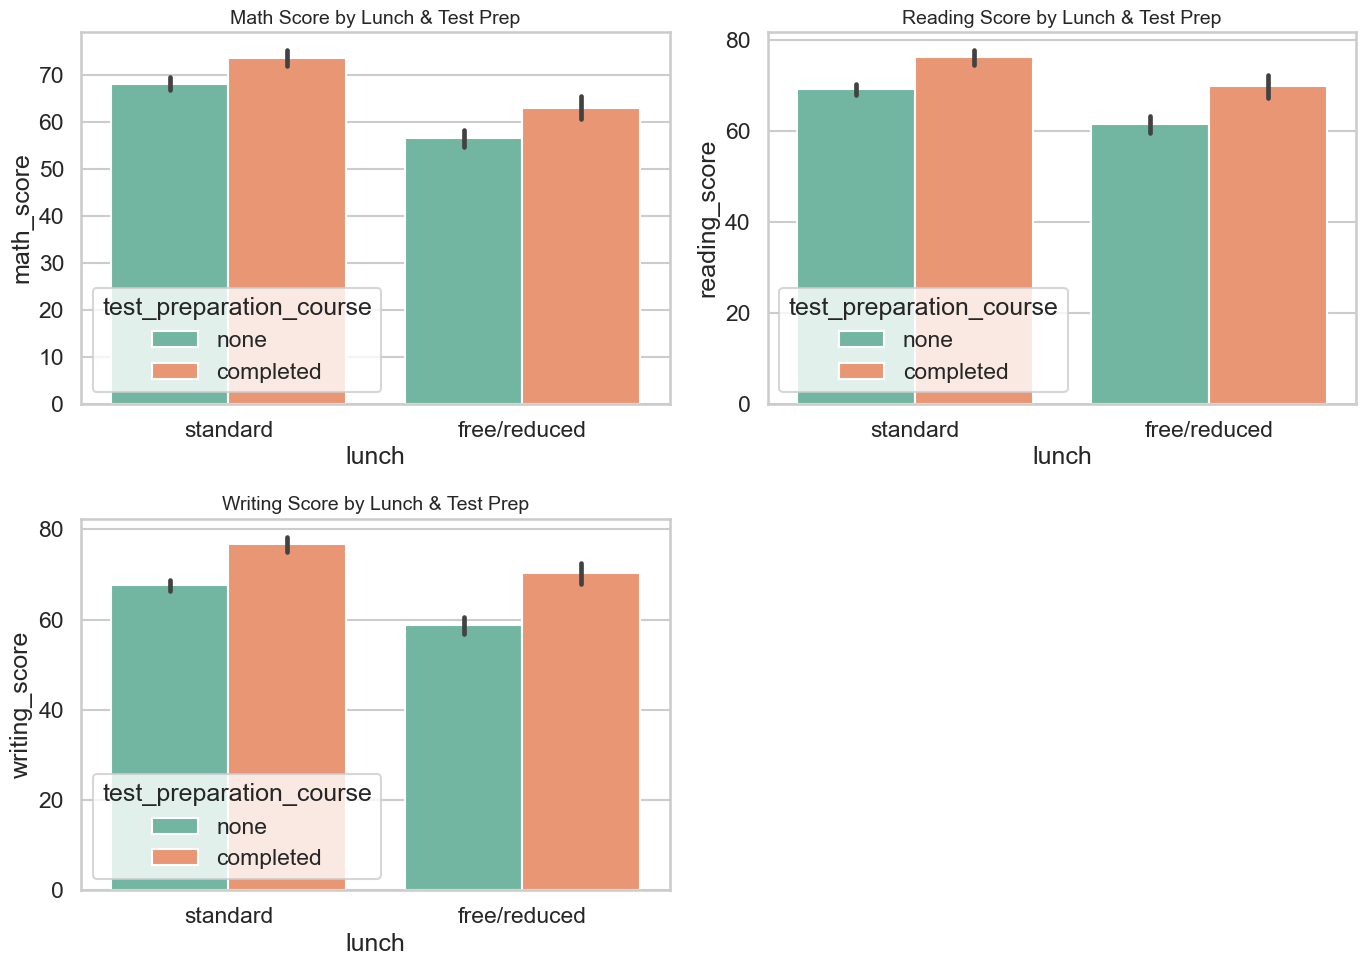

In [57]:
plt.figure(figsize=(14,10))

# Math Score
plt.subplot(2,2,1)
sns.barplot(
    x='lunch',
    y='math_score',
    hue='test_preparation_course',
    data=df,
    palette='Set2'
)
plt.title('Math Score by Lunch & Test Prep', fontsize=14)

# Reading Score
plt.subplot(2,2,2)
sns.barplot(
    x='lunch',
    y='reading_score',
    hue='test_preparation_course',
    data=df,
    palette='Set2'
)
plt.title('Reading Score by Lunch & Test Prep', fontsize=14)

# Writing Score
plt.subplot(2,2,3)
sns.barplot(
    x='lunch',
    y='writing_score',
    hue='test_preparation_course',
    data=df,
    palette='Set2'
)
plt.title('Writing Score by Lunch & Test Prep', fontsize=14)

plt.tight_layout()
plt.show()

## Insights

- Students who have **completed the Test Preparation Course** have higher scores in all three subjects compared to those who haven't taken the course.  

## 4.4.6 Checking Outliers

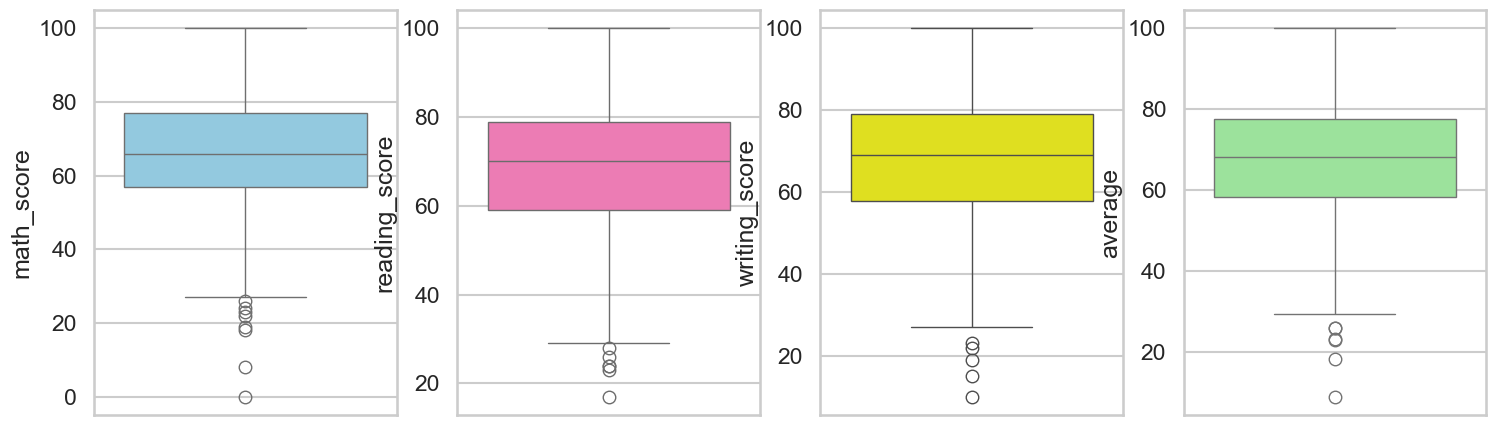

In [59]:
plt.subplots(1,4,figsize=(16,5))
plt.subplot(141)
sns.boxplot(df['math_score'],color='skyblue')
plt.subplot(142)
sns.boxplot(df['reading_score'],color='hotpink')
plt.subplot(143)
sns.boxplot(df['writing_score'],color='yellow')
plt.subplot(144)
sns.boxplot(df['average'],color='lightgreen')
plt.show()

4.4.7 MUTIVARIATE ANALYSIS USING PAIRPLOT

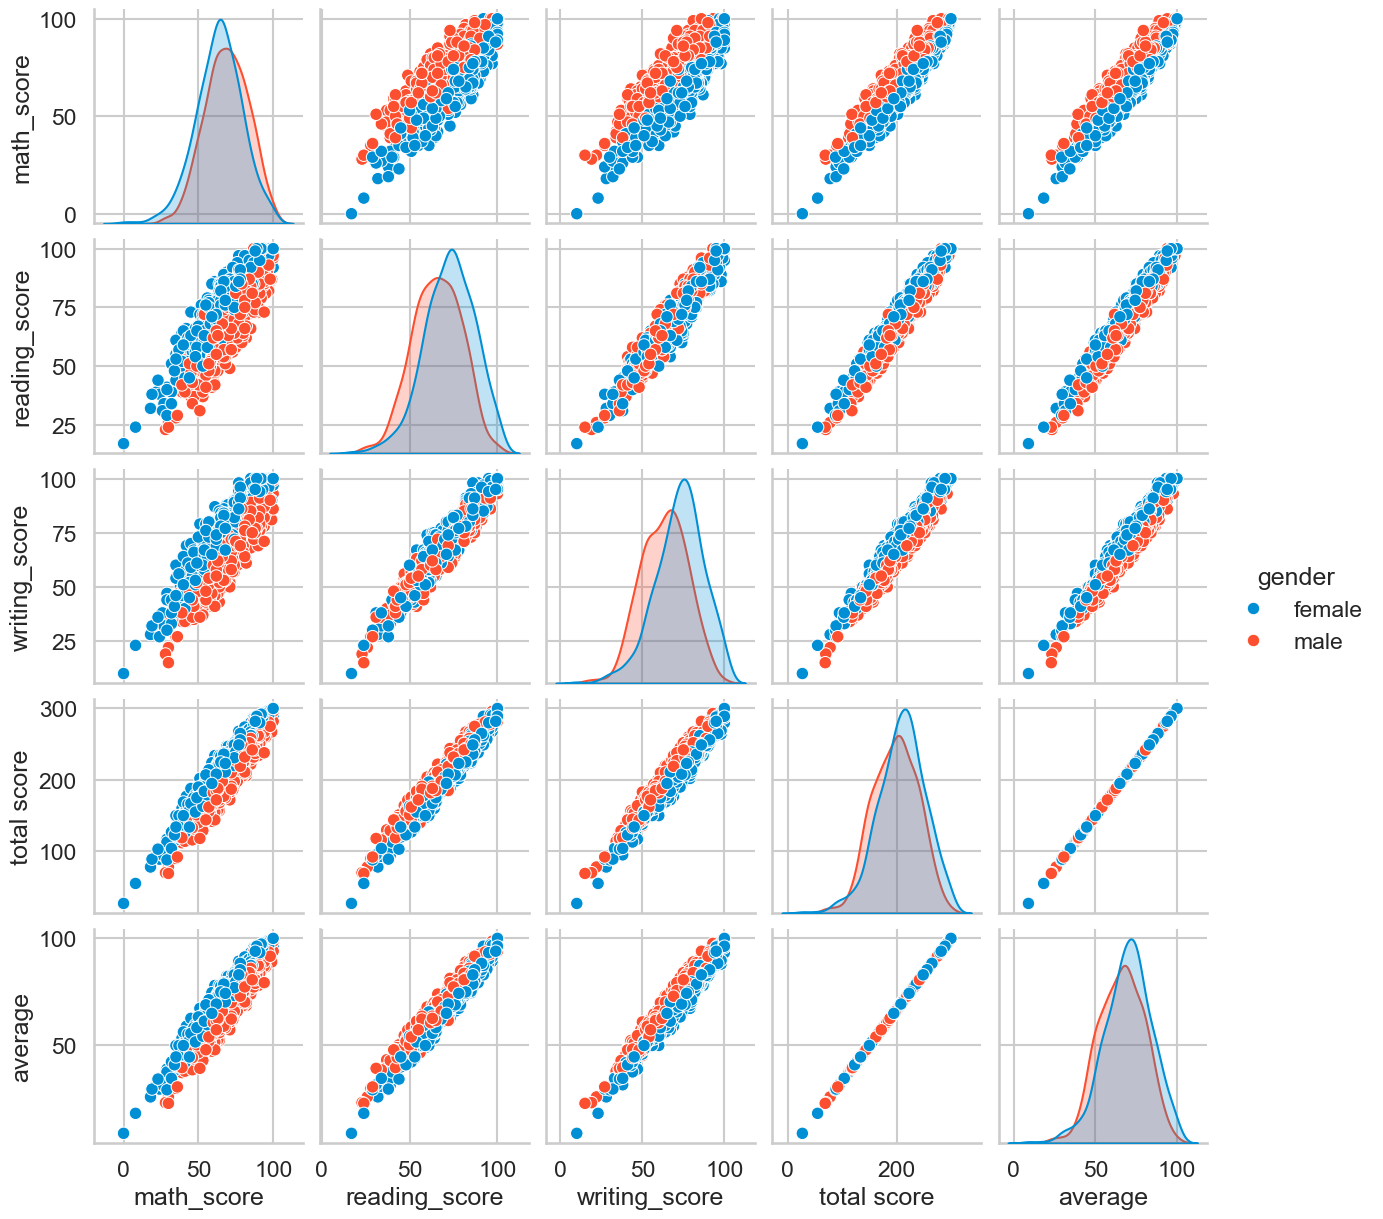

In [60]:
sns.pairplot(df,hue = 'gender')
plt.show()

## Insights

- From the above plot, it is clear that **all the scores increase linearly with each other**.  

## 5. Conclusions

- Student's performance is related to **lunch type, race/ethnicity, and parental level of education**.  
- **Female students** lead in **pass percentage** and are also **top-scorers**.  
- Student's performance is **not strongly related** with test preparation course.  
- **Completing the test preparation course** is still beneficial for higher scores.